<a href="https://colab.research.google.com/github/yuvipaloozie/Regime-Aware-Sector-Trading/blob/main/notebooks/Regime_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- REVISED CELL 1 & 2: Weekly Aggregation & Grounded Feature Engineering ---
!pip install yfinance pandas-datareader statsmodels hmmlearn scikit-learn

import yfinance as yf
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Starting earlier provides a sufficient warm-up period for the weekly walk-forward window
START_DATE = '1998-01-01'
END_DATE = '2026-05-01'

print("Ingesting data and strictly resampling to Weekly (Friday)...")
eq_data = yf.download(['SPY', '^VIX'], start=START_DATE, end=END_DATE)['Close']
eq_data.columns = ['SPY', 'VIX']

print("Ingesting macro data from Federal Reserve (FRED)...")
fred_data = web.DataReader(['T10Y2Y', 'STLFSI4'], 'fred', START_DATE, END_DATE)

# Point-in-Time Alignment:
# 1. Join daily to preserve exact publication dates.
# 2. Forward-fill to ensure no NaNs before resampling.
# 3. Resample strictly to Friday Close (W-FRI).
df_daily = eq_data.join(fred_data, how='left').ffill().dropna()
df_weekly = df_daily.resample('W-FRI').last()

print(f"Data resampled to Weekly frequency. Operational shape: {df_weekly.shape}")

# Feature Engineering
df_features = pd.DataFrame(index=df_weekly.index)

# 1. Weekly Log Returns
df_features['SPY_Log_Ret_W'] = np.log(df_weekly['SPY'] / df_weekly['SPY'].shift(1))

# 2. Implied Risk & Stress (End of Week Levels / Weekly Differences)
df_features['VIX_Level'] = df_weekly['VIX']
df_features['Yield_Curve_Change_W'] = df_weekly['T10Y2Y'].diff(1)
df_features['Financial_Stress'] = df_weekly['STLFSI4']

df_features = df_features.dropna()

print("="*60)
print("     AUGMENTED DICKEY-FULLER STATIONARITY TEST (WEEKLY)   ")
print("="*60)

features_to_use = ['SPY_Log_Ret_W', 'VIX_Level', 'Yield_Curve_Change_W', 'Financial_Stress']
for feature in features_to_use:
    result = adfuller(df_features[feature])
    status = "STATIONARY (Pass)" if result[1] < 0.05 else "NON-STATIONARY (Warning)"
    print(f"Factor: {feature:<20} | ADF Stat: {result[0]:>7.4f} | P-Value: {result[1]:.4e} | {status}")
print("="*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 11.2 MB/s eta 0:00:00
Ingesting data and strictly resampling to Weekly (Friday)...


[*********************100%***********************]  2 of 2 completed


Ingesting macro data from Federal Reserve (FRED)...
Data resampled to Weekly frequency. Operational shape: (1479, 4)
     AUGMENTED DICKEY-FULLER STATIONARITY TEST (WEEKLY)   
Factor: SPY_Log_Ret_W        | ADF Stat: -15.7669 | P-Value: 1.1735e-28 | STATIONARY (Pass)
Factor: VIX_Level            | ADF Stat: -4.6066 | P-Value: 1.2562e-04 | STATIONARY (Pass)
Factor: Yield_Curve_Change_W | ADF Stat: -8.8698 | P-Value: 1.4079e-14 | STATIONARY (Pass)
Factor: Financial_Stress     | ADF Stat: -4.7341 | P-Value: 7.2578e-05 | STATIONARY (Pass)



Executing Bayesian Information Criterion (BIC) Sweep to find Optimal N_STATES...
Fit 2 States | BIC:  12978.6 | Log-Likelihood:  -6423.6
Fit 3 States | BIC:  11277.0 | Log-Likelihood:  -5529.0
Fit 4 States | BIC:  10658.1 | Log-Likelihood:  -5168.5
Fit 5 States | BIC:  10560.8 | Log-Likelihood:  -5061.5
Fit 6 States | BIC:  10026.2 | Log-Likelihood:  -4728.5
Fit 7 States | BIC:   9746.2 | Log-Likelihood:  -4515.5


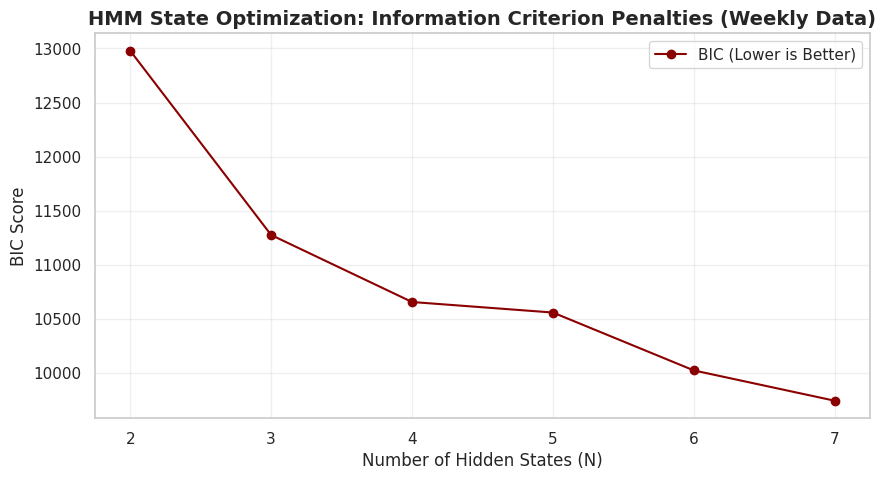


CONCLUSION: The Bayesian Information Criterion (BIC) minimizes at N = 7 States.



In [ ]:
# ==============================================================================
# --- REVISED CELL 2.5: Regime Sensitivity Analysis (BIC Optimization) ---
# ==============================================================================
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import numpy as np
import warnings
import logging
from sklearn.preprocessing import StandardScaler

logging.getLogger("hmmlearn").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

print("\nExecuting Bayesian Information Criterion (BIC) Sweep to find Optimal N_STATES...")

# 7 states is the absolute maximum viable for weekly macro data
state_range = range(2, 8)
bic_scores = []

X_full_scaled = StandardScaler().fit_transform(df_features[features_to_use].values)
n_samples = len(X_full_scaled)
n_features = X_full_scaled.shape[1]

for n_states in state_range:
    log_likelihood = None
    for attempt in range(5):
        try:
            # Switched to GaussianHMM for weekly data stability
            model = GaussianHMM(n_components=n_states, covariance_type="diag",
                           n_iter=1000, random_state=42 + attempt)
            model.fit(X_full_scaled)
            log_likelihood = model.score(X_full_scaled)
            break
        except ValueError:
            continue

    if log_likelihood is None:
        bic_scores.append(np.inf)
        continue

    # Free parameters for GaussianHMM: transitions + means + variances
    k = (n_states**2 - n_states) + (n_states * n_features) + (n_states * n_features)
    bic = k * np.log(n_samples) - 2 * log_likelihood
    bic_scores.append(bic)
    print(f"Fit {n_states} States | BIC: {bic:>8.1f} | Log-Likelihood: {log_likelihood:>8.1f}")

plt.figure(figsize=(10, 5))
plt.plot(state_range, bic_scores, marker='o', linestyle='-', color='darkred', label='BIC (Lower is Better)')
plt.title('HMM State Optimization: Information Criterion Penalties (Weekly Data)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Hidden States (N)', fontsize=12)
plt.ylabel('BIC Score', fontsize=12)
plt.xticks(state_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

valid_bics = [b for b in bic_scores if b != np.inf]
if valid_bics:
    optimal_n = state_range[np.argmin(valid_bics)]
    print(f"\nCONCLUSION: The Bayesian Information Criterion (BIC) minimizes at N = {optimal_n} States.\n")
# ==============================================================================

In [ ]:
# --- REVISED CELL 3: Out-of-Sample Walk-Forward Engine (State Anchoring) ---
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import warnings
import logging
import numpy as np
import pandas as pd

logging.getLogger("hmmlearn").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

print("Initializing Robust Walk-Forward HMM Execution...")

# Weekly Parameters
STEP_SIZE = 4       # Retrain model every 4 weeks (approx. 1 month)
WINDOW_SIZE = 260   # 5-year rolling training window (52 weeks * 5)
N_STATES = 3        # <--- Changed to 3 States

out_of_sample_predictions = []
prediction_dates = []

feature_array = df_features[features_to_use].values
dates_array = df_features.index

for t in range(WINDOW_SIZE, len(df_features), STEP_SIZE):
    X_train_raw = feature_array[t - WINDOW_SIZE : t]

    end_idx = min(t + STEP_SIZE, len(df_features))
    X_test_raw = feature_array[t : end_idx]
    dates_test = dates_array[t : end_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    hmm_model = GaussianHMM(n_components=N_STATES, covariance_type="diag",
                            n_iter=1000, random_state=42)

    try:
        hmm_model.fit(X_train_scaled)
    except ValueError:
        print(f"Convergence warning at {dates_test[0].date()}, carrying forward parameters.")
        pass

    # --- Strict Label Anchoring ---
    # Predict on training data to assess empirical returns of each latent state
    train_preds = hmm_model.predict(X_train_scaled)
    state_metrics = []

    for i in range(N_STATES):
        mask = (train_preds == i)
        # Calculate mean weekly return for the state. Default to -inf if empty.
        mean_ret = X_train_raw[mask, 0].mean() if np.sum(mask) > 0 else -np.inf
        state_metrics.append((i, mean_ret))

    # Sort states by highest mean return (descending)
    state_metrics.sort(key=lambda x: x[1], reverse=True)

    # Create mapping: {Original_Model_Label: New_Anchored_Label}
    # Label 0 = Highest Return (Expansion), Label 2 = Lowest Return (Crisis)
    label_map = {old_idx: new_idx for new_idx, (old_idx, _) in enumerate(state_metrics)}

    # Predict Out-of-Sample and apply the strict mapping
    test_preds_raw = hmm_model.predict(X_test_scaled)
    test_preds_mapped = [label_map[p] for p in test_preds_raw]

    out_of_sample_predictions.extend(test_preds_mapped)
    prediction_dates.extend(dates_test)

    if (t - WINDOW_SIZE) % (STEP_SIZE * 13) == 0:
        print(f"[{dates_array[t].date()}] Walk-Forward Training Completed... Proceeding.")

oos_regimes = pd.Series(out_of_sample_predictions, index=prediction_dates, name='OOS_Regime')
df_oos = df_features.loc[oos_regimes.index].copy()
df_oos['OOS_Regime'] = oos_regimes

print("Walk-Forward Execution Complete. Regimes successfully anchored.")

Initializing Robust Walk-Forward HMM Execution...
[2003-01-03] Walk-Forward Training Completed... Proceeding.
[2004-01-02] Walk-Forward Training Completed... Proceeding.
[2004-12-31] Walk-Forward Training Completed... Proceeding.
[2005-12-30] Walk-Forward Training Completed... Proceeding.
[2006-12-29] Walk-Forward Training Completed... Proceeding.
[2007-12-28] Walk-Forward Training Completed... Proceeding.
[2008-12-26] Walk-Forward Training Completed... Proceeding.
[2009-12-25] Walk-Forward Training Completed... Proceeding.
[2010-12-24] Walk-Forward Training Completed... Proceeding.
[2011-12-23] Walk-Forward Training Completed... Proceeding.
[2012-12-21] Walk-Forward Training Completed... Proceeding.
[2013-12-20] Walk-Forward Training Completed... Proceeding.
[2014-12-19] Walk-Forward Training Completed... Proceeding.
[2015-12-18] Walk-Forward Training Completed... Proceeding.
[2016-12-16] Walk-Forward Training Completed... Proceeding.
[2017-12-15] Walk-Forward Training Completed... Pr

Generating Kernel Density Estimates (KDE) for Out-of-Sample Weekly Features...


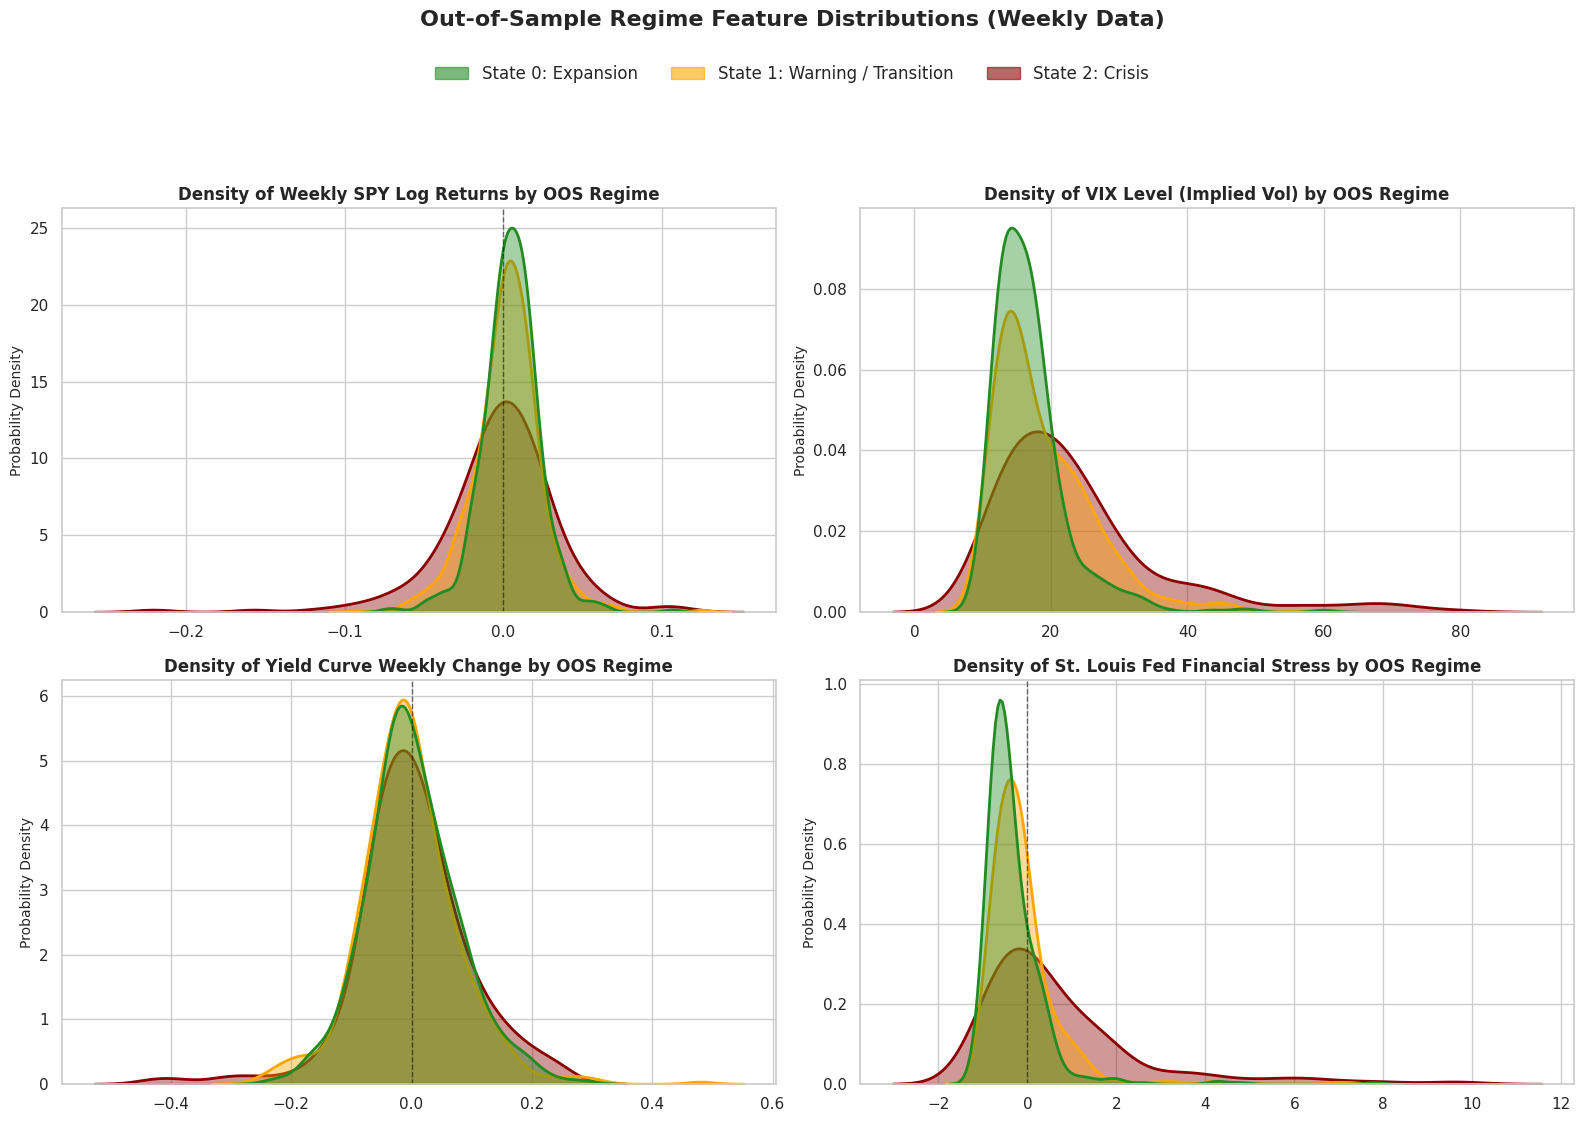

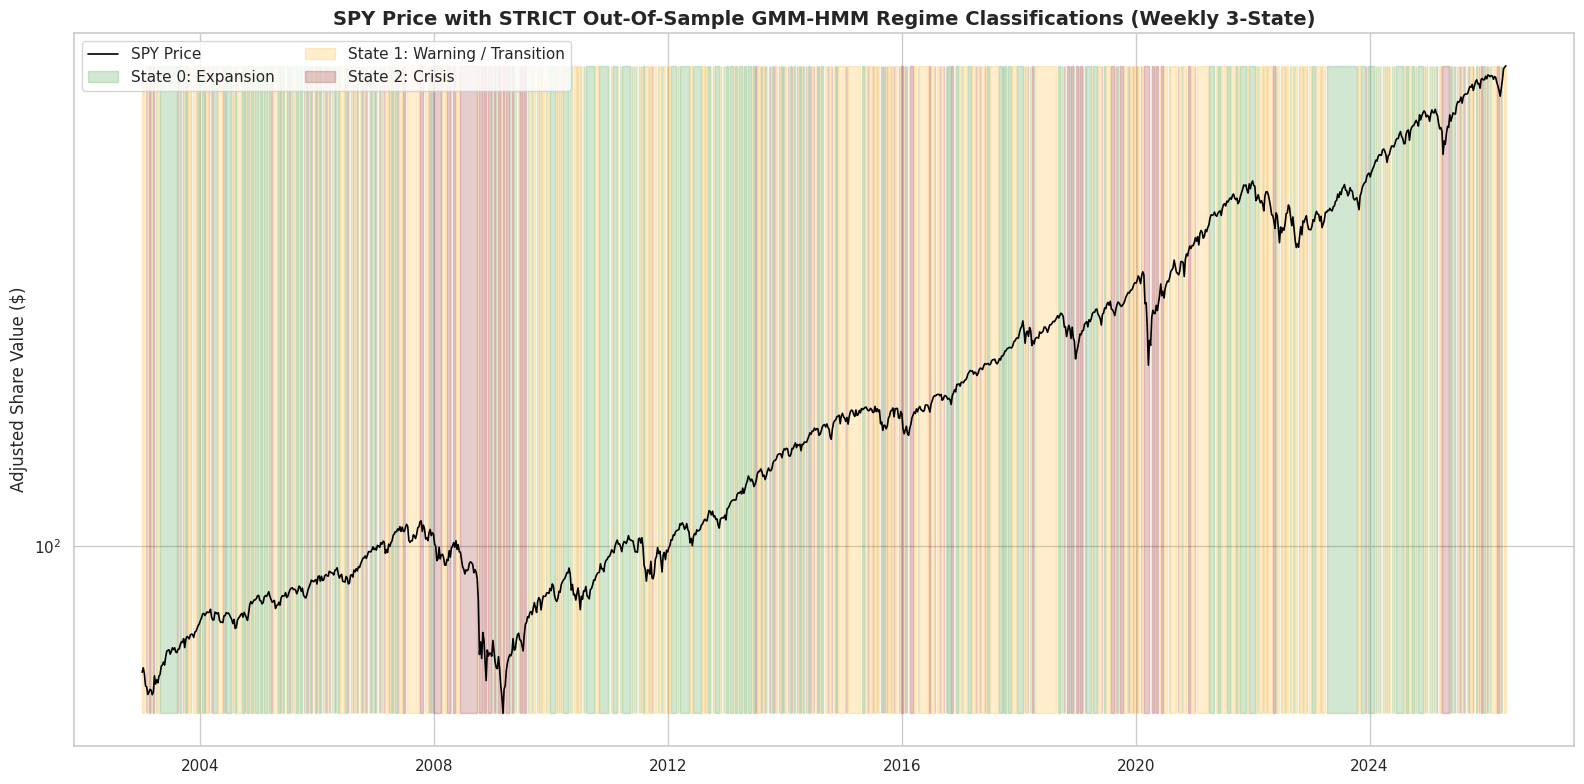

       TRUE OUT-OF-SAMPLE REGIME PROFILE MATRIX (Predictive Validity)      
            Annualized_Return_%  Annualized_Volatility_%  Sharpe_Ratio  \
OOS_Regime                                                               
0                         27.73                    13.08          2.12   
1                         10.21                    15.35          0.67   
2                        -14.32                    26.55         -0.54   

            Avg_VIX  Avg_Fin_Stress  
OOS_Regime                           
0             16.80           -0.33  
1             18.87           -0.12  
2             23.68            0.72  


In [ ]:
# --- REVISED CELL 3.5, 4, & 5: Weekly Visualization & Validation Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

print("Generating Kernel Density Estimates (KDE) for Out-of-Sample Weekly Features...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

features_to_plot = ['SPY_Log_Ret_W', 'VIX_Level', 'Yield_Curve_Change_W', 'Financial_Stress']
titles = ['Weekly SPY Log Returns', 'VIX Level (Implied Vol)',
          'Yield Curve Weekly Change', 'St. Louis Fed Financial Stress']

color_map = {0: 'forestgreen', 1: 'orange', 2: 'darkred'}
legend_labels = {0: 'State 0: Expansion', 1: 'State 1: Warning / Transition',
                 2: 'State 2: Crisis'}

for i, feature in enumerate(features_to_plot):
    sns.kdeplot(data=df_oos, x=feature, hue='OOS_Regime', palette=color_map,
                fill=True, common_norm=False, alpha=0.4, linewidth=2, ax=axes[i], legend=False)
    axes[i].set_title(f'Density of {titles[i]} by OOS Regime', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Probability Density', fontsize=10)
    axes[i].set_xlabel('')
    if feature in ['SPY_Log_Ret_W', 'Yield_Curve_Change_W', 'Financial_Stress']:
        axes[i].axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)

patches = [mpatches.Patch(color=color_map[k], label=legend_labels[k], alpha=0.6) for k in range(3)]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, fontsize=12, frameon=False)
plt.suptitle('Out-of-Sample Regime Feature Distributions (Weekly Data)', fontsize=16, fontweight='bold', y=1.12)
plt.tight_layout()
plt.show()

# --- Out-Of-Sample Latent State Overlays ---
plt.figure(figsize=(16, 8))
spy_prices = df_weekly.loc[df_oos.index, 'SPY']

plt.plot(spy_prices.index, spy_prices.values, color='black', linewidth=1.2, label='SPY Price')
state_series = df_oos['OOS_Regime']

for state in range(3):
    mask = (state_series == state)
    plt.fill_between(spy_prices.index, spy_prices.min(), spy_prices.max(),
                     where=mask, color=color_map[state], alpha=0.2, label=legend_labels[state])

plt.title('SPY Price with STRICT Out-Of-Sample GMM-HMM Regime Classifications (Weekly 3-State)', fontsize=14, fontweight='bold')
plt.ylabel('Adjusted Share Value ($)', fontsize=12)
plt.yscale('log')
plt.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

# --- Out-Of-Sample Statistical Validation Matrix (Weekly Math) ---
profile = df_oos.groupby('OOS_Regime').agg({
    'SPY_Log_Ret_W': ['mean', 'std'],
    'VIX_Level': ['mean'],
    'Financial_Stress': ['mean']
})

profile.columns = ['Mean_Log_Return', 'Return_Vol', 'Avg_VIX', 'Avg_Fin_Stress']

# Crucial Change: Annualizing weekly data requires 52, not 252
profile['Annualized_Return_%'] = (np.exp(profile['Mean_Log_Return'] * 52) - 1) * 100
profile['Annualized_Volatility_%'] = (profile['Return_Vol'] * np.sqrt(52)) * 100
profile['Sharpe_Ratio'] = profile['Annualized_Return_%'] / profile['Annualized_Volatility_%']

print("="*85)
print("       TRUE OUT-OF-SAMPLE REGIME PROFILE MATRIX (Predictive Validity)      ")
print("="*85)
cols_to_print = ['Annualized_Return_%', 'Annualized_Volatility_%', 'Sharpe_Ratio', 'Avg_VIX', 'Avg_Fin_Stress']
print(profile[cols_to_print].round(2))
print("="*85)

In [ ]:
# --- REVISED CELL 6: Weekly Signal Smoothing & Vector Export ---
import numpy as np
import pandas as pd

# 1. SIGNAL SMOOTHING (Hysteresis Filter)
df_export = pd.DataFrame(index=df_oos.index)
df_export['Raw_OOS_Regime'] = df_oos['OOS_Regime']

# Use a 3-week rolling window to find the mode (prevents 1-week whiplash)
df_export['Smoothed_Regime'] = df_export['Raw_OOS_Regime'].rolling(window=3).apply(lambda x: pd.Series(x).mode()[0]).fillna(df_export['Raw_OOS_Regime'])
df_export['Smoothed_Regime'] = df_export['Smoothed_Regime'].astype(int)

# 2. TIERED POSITION SIZING (The Risk Scalar)
conditions = [
    df_export['Smoothed_Regime'] == 0, # Expansion
    df_export['Smoothed_Regime'] == 1, # Warning
    df_export['Smoothed_Regime'] == 2  # Crisis
]
# Adjusted choices to reflect weekly sector rotation confidence for 3 states
choices = [1.0, 0.6, 0.0]

df_export['Risk_Scalar'] = np.select(conditions, choices, default=1.0)

print("="*60)
print("     FINAL MACRO SIGNAL DISTRIBUTION (SMOOTHED WEEKLY)      ")
print("="*60)
print("Regime Breakdown (Smoothed):")
print(df_export['Smoothed_Regime'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print("-" * 60)

output_filename = "oos_macro_regime_vector_weekly.csv"
df_export[['Smoothed_Regime', 'Risk_Scalar']].to_csv(output_filename)
print(f"\nSUCCESS: Tradeable Out-Of-Sample array stored locally as '{output_filename}'.")

     FINAL MACRO SIGNAL DISTRIBUTION (SMOOTHED WEEKLY)      
Regime Breakdown (Smoothed):
Smoothed_Regime
0    47.9%
1    38.5%
2    13.5%
Name: proportion, dtype: object
------------------------------------------------------------

SUCCESS: Tradeable Out-Of-Sample array stored locally as 'oos_macro_regime_vector_weekly.csv'.


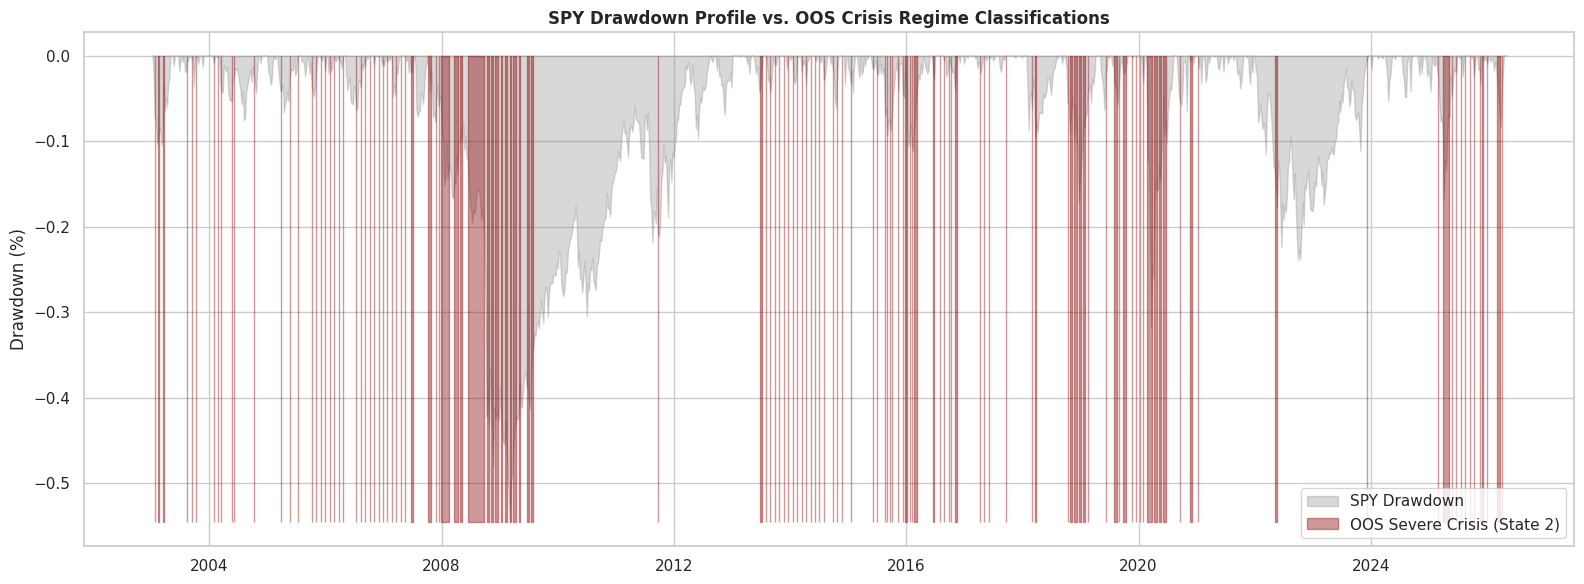

In [ ]:
# --- NEW CELL: Drawdown Overlay Visualization ---
# Calculate rolling SPY drawdown
cum_returns = (1 + df_weekly.loc[df_oos.index, 'SPY'].pct_change().fillna(0)).cumprod()
peak = cum_returns.cummax()
drawdown = (cum_returns - peak) / peak

plt.figure(figsize=(16, 6))
plt.fill_between(drawdown.index, drawdown, 0, color='gray', alpha=0.3, label='SPY Drawdown')

# Shade Crisis Regimes (State 2) in Dark Red
crisis_mask = (df_oos['OOS_Regime'] == 2)
plt.fill_between(drawdown.index, drawdown.min(), 0,
                 where=crisis_mask, color='darkred', alpha=0.4, label='OOS Severe Crisis (State 2)')

plt.title('SPY Drawdown Profile vs. OOS Crisis Regime Classifications', fontweight='bold')
plt.ylabel('Drawdown (%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

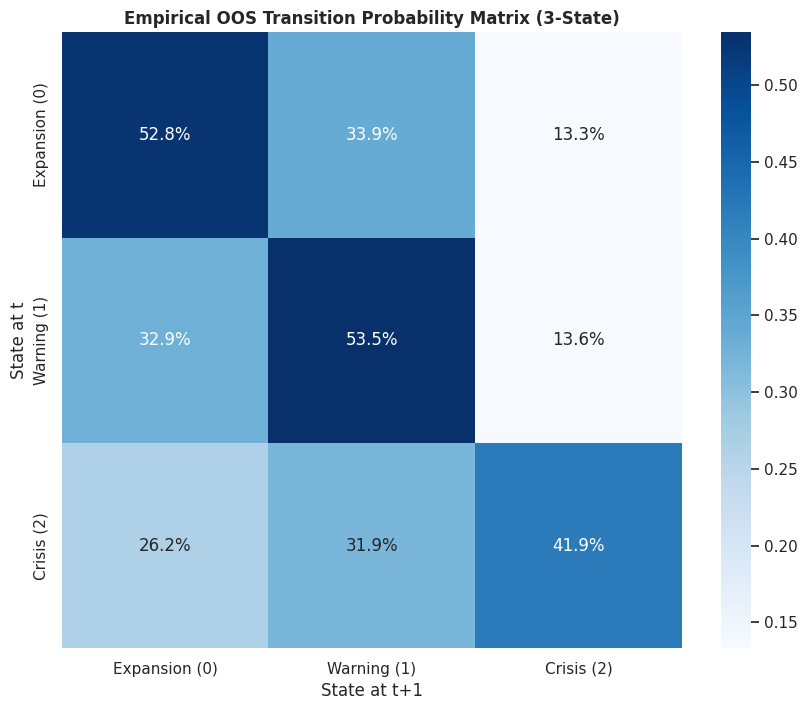

In [ ]:
# --- NEW CELL: Transition Probability Heatmap ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Shift the OOS regime vector by 1 day to see t -> t+1 transitions
oos_current = df_oos['OOS_Regime'].iloc[:-1]
oos_next = df_oos['OOS_Regime'].iloc[1:]

# Calculate raw transition counts and normalize by row (current state)
trans_matrix = confusion_matrix(oos_current, oos_next, normalize='true')

plt.figure(figsize=(10, 8))
labels = ['Expansion (0)', 'Warning (1)', 'Crisis (2)']
sns.heatmap(trans_matrix, annot=True, fmt=".1%", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title('Empirical OOS Transition Probability Matrix (3-State)', fontweight='bold')
plt.xlabel('State at t+1')
plt.ylabel('State at t')
plt.show()

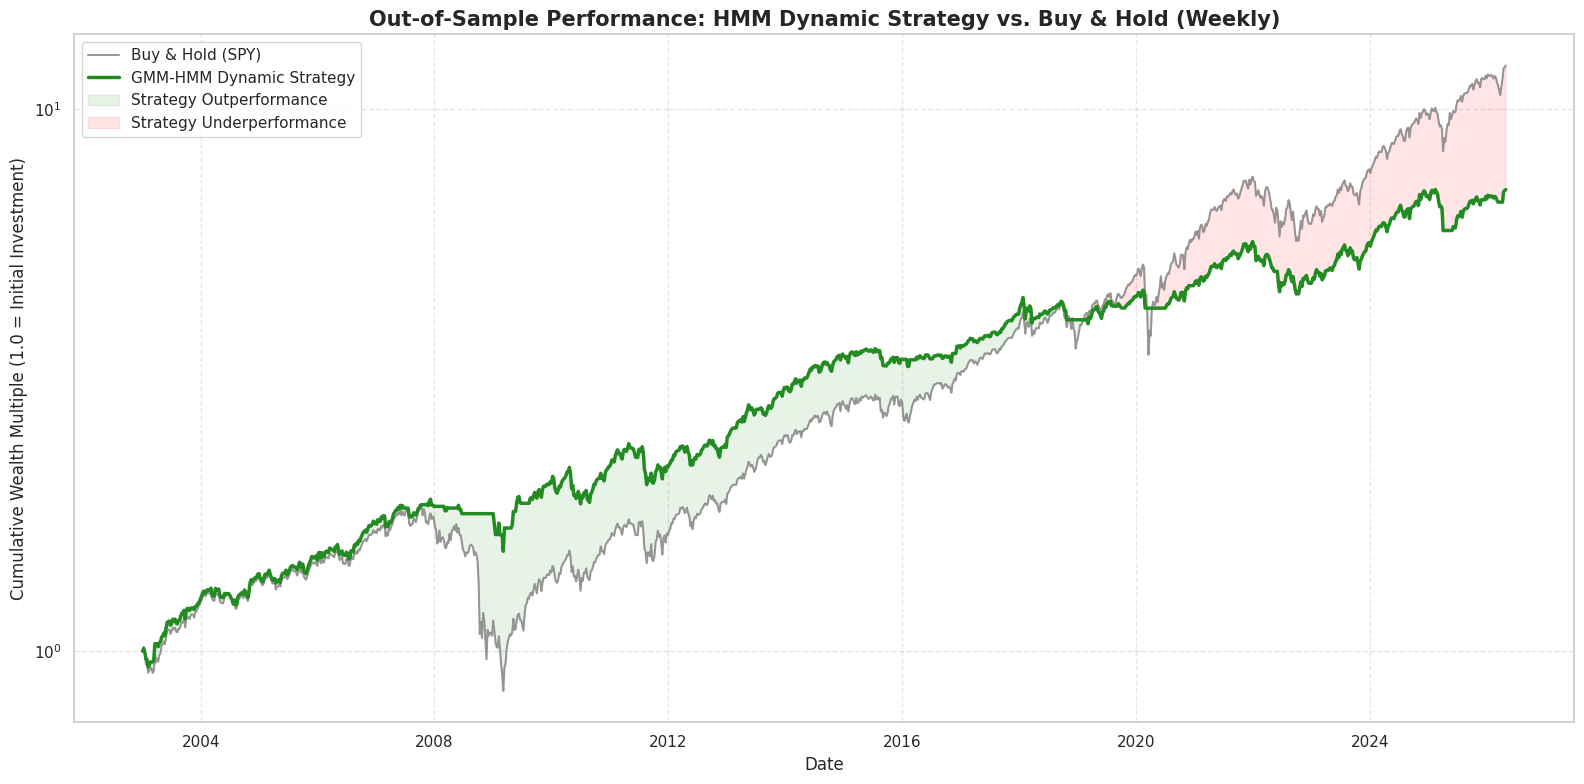

          OUT-OF-SAMPLE PERFORMANCE SUMMARY (WEEKLY)        
Buy & Hold Total Return:       1104.50%
HMM Strategy Total Return:      611.37%
--------------------------------------------------
Buy & Hold Ann. Volatility:      17.20%
HMM Strategy Ann. Volatility:    10.95%
--------------------------------------------------
Buy & Hold Sharpe Ratio:          0.71
HMM Strategy Sharpe Ratio:        0.82


In [ ]:
# --- REVISED Cell 9: Strategy Backtest vs Buy & Hold (Weekly) ---
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Simple Weekly Returns for SPY
spy_returns = df_weekly.loc[df_oos.index, 'SPY'].pct_change().fillna(0)

# 2. PREVENT LOOKAHEAD BIAS: Shift the Risk Scalar by 1 period (week).
# The regime identified at the close of week 't' can only be applied to the return of week 't+1'.
strategy_weights = df_export['Risk_Scalar'].shift(1).fillna(1.0) # Assume fully invested on week 1

# 3. Calculate Strategy Returns
strategy_returns = spy_returns * strategy_weights

# 4. Calculate Cumulative Returns (Wealth Index)
cum_spy = (1 + spy_returns).cumprod()
cum_strategy = (1 + strategy_returns).cumprod()

# 5. Visualization
plt.figure(figsize=(16, 8))
plt.plot(cum_spy.index, cum_spy, label='Buy & Hold (SPY)', color='gray', alpha=0.8, linewidth=1.5)
plt.plot(cum_strategy.index, cum_strategy, label='GMM-HMM Dynamic Strategy', color='forestgreen', linewidth=2.5)

# Highlight outperformance/underperformance areas
plt.fill_between(cum_strategy.index, cum_spy, cum_strategy,
                 where=(cum_strategy > cum_spy), color='forestgreen', alpha=0.1, label='Strategy Outperformance')
plt.fill_between(cum_strategy.index, cum_spy, cum_strategy,
                 where=(cum_strategy < cum_spy), color='red', alpha=0.1, label='Strategy Underperformance')

plt.title('Out-of-Sample Performance: HMM Dynamic Strategy vs. Buy & Hold (Weekly)', fontsize=15, fontweight='bold')
plt.ylabel('Cumulative Wealth Multiple (1.0 = Initial Investment)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.yscale('log') # Log scale is better for visualizing compounding over a decade
plt.tight_layout()
plt.show()

# 6. Performance Summary
spy_tot_ret = (cum_spy.iloc[-1] - 1) * 100
strat_tot_ret = (cum_strategy.iloc[-1] - 1) * 100

# Crucial Change: Annualizing weekly data requires 52, not 252
spy_ann_vol = spy_returns.std() * np.sqrt(52) * 100
strat_ann_vol = strategy_returns.std() * np.sqrt(52) * 100

# Calculate Sharpe Ratio (Assuming 0% risk-free rate for baseline comparison)
spy_sharpe = (spy_returns.mean() / spy_returns.std()) * np.sqrt(52)
strat_sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(52)

print("="*50)
print("          OUT-OF-SAMPLE PERFORMANCE SUMMARY (WEEKLY)        ")
print("="*50)
print(f"Buy & Hold Total Return:      {spy_tot_ret:>8.2f}%")
print(f"HMM Strategy Total Return:    {strat_tot_ret:>8.2f}%")
print("-"*50)
print(f"Buy & Hold Ann. Volatility:   {spy_ann_vol:>8.2f}%")
print(f"HMM Strategy Ann. Volatility: {strat_ann_vol:>8.2f}%")
print("-"*50)
print(f"Buy & Hold Sharpe Ratio:      {spy_sharpe:>8.2f}")
print(f"HMM Strategy Sharpe Ratio:    {strat_sharpe:>8.2f}")
print("="*50)
